In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\DSBDA\DSBDA Project\Cleaned_data_for_model.csv")

In [4]:
df.head()

,Unnamed: 0,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0


In [32]:
# Drop useless column
df.drop(columns=['Unnamed: 0'], inplace=True)


In [33]:
# Convert all categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes

In [34]:
# Remove null values
df = df.dropna()

In [35]:
# Check
print(df.dtypes)

property_type       int8
price              int64
location           int16
city                int8
baths              int64
purpose             int8
bedrooms           int64
Area_in_Marla    float64
dtype: object


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92214 entries, 0 to 99498
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  92214 non-null  int8   
 1   price          92214 non-null  int64  
 2   location       92214 non-null  int16  
 3   city           92214 non-null  int8   
 4   baths          92214 non-null  int64  
 5   purpose        92214 non-null  int8   
 6   bedrooms       92214 non-null  int64  
 7   Area_in_Marla  92214 non-null  float64
dtypes: float64(1), int16(1), int64(3), int8(3)
memory usage: 4.0 MB


In [37]:
df.describe()

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
count,92214.000000,9.221400e+04,92214.000000,92214.000000,92214.000000,92214.000000,92214.000000,92214.000000
mean,2.158577,8.315569e+06,521.742989,2.212603,3.406131,0.690600,3.252489,8.192106
std,1.346211,7.927100e+06,344.310445,1.007691,1.418459,0.462249,1.219575,6.588280
min,0.000000,1.550000e+04,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.100000e+05,209.000000,1.000000,2.000000,0.000000,2.000000,4.700000
50%,2.000000,6.600000e+06,441.000000,2.000000,3.000000,1.000000,3.000000,6.000000
75%,2.000000,1.400000e+07,744.000000,3.000000,4.000000,1.000000,4.000000,10.000000
max,6.000000,2.990000e+07,1388.000000,4.000000,7.000000,1.000000,6.000000,96.000000


In [7]:
df.shape

(99499, 9)

In [38]:
df.isnull().sum()

property_type    0
price            0
location         0
city             0
baths            0
purpose          0
bedrooms         0
Area_in_Marla    0
dtype: int64

In [39]:
df[df.duplicated()]

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
43,2,21500000,139,3,5,1,4,10.0
47,2,23000000,139,3,5,1,4,10.0
168,6,75000,410,1,3,0,3,20.0
172,2,55000,144,4,4,0,3,5.0
180,2,23000000,139,3,5,1,4,10.0
...,...,...,...,...,...,...,...,...
99494,1,7500000,189,2,3,1,3,8.0
99495,2,8800000,189,2,4,1,3,8.0
99496,2,14000000,189,2,3,1,3,8.0
99497,2,14000000,189,2,4,1,4,14.0


In [40]:
df['location'] = df['location'].astype('category').cat.codes

In [41]:
df['location']

0        450
1        380
2        455
4        326
5        380
        ... 
99494    189
99495    189
99496    189
99497    189
99498    189
Name: location, Length: 92214, dtype: int16

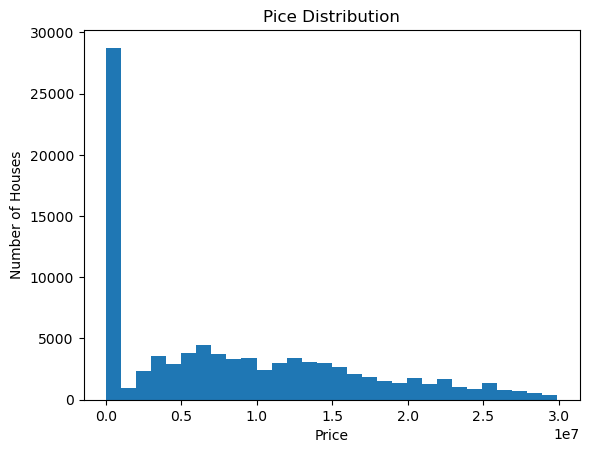

In [42]:
plt.hist(df['price'],bins=30)
plt.title("Pice Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()



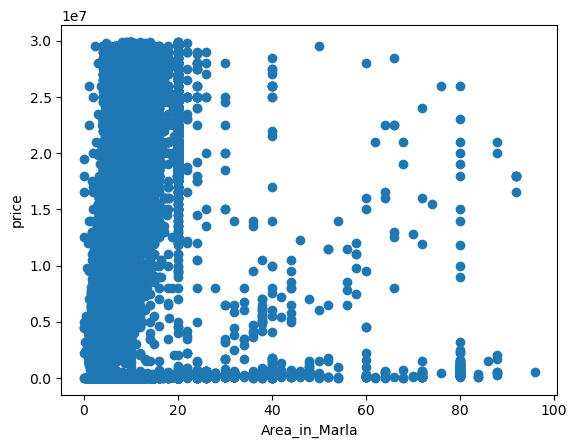

In [43]:
plt.scatter(df['Area_in_Marla'],df['price'])
plt.xlabel("Area_in_Marla")
plt.ylabel("price")
plt.show()

In [44]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

threshold = Q3 + 1.5 * IQR

In [45]:
df = df[df['price'] < threshold]

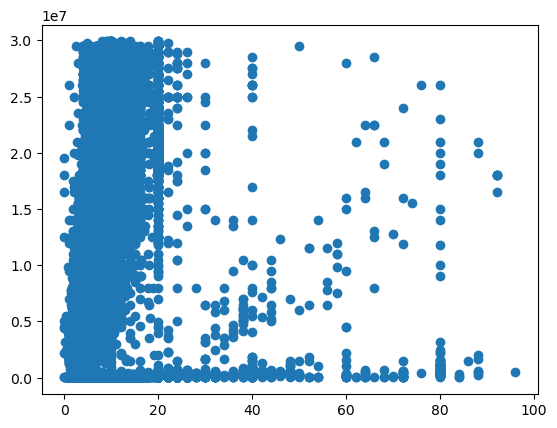

In [46]:
plt.scatter(df['Area_in_Marla'], df['price'])
plt.show()

In [47]:
df = df[df['price'] > 0]

In [48]:
threshold = 30000000   # 3 crore
df = df[df['price'] < threshold]

In [49]:
df = df[df['Area_in_Marla'] < 100]

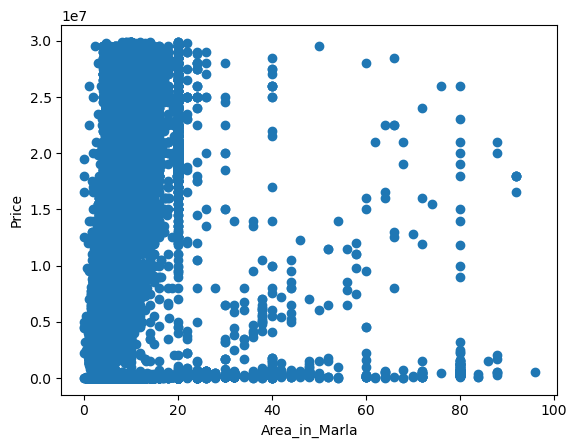

In [50]:
plt.scatter(df['Area_in_Marla'], df['price'])
plt.xlabel("Area_in_Marla")
plt.ylabel("Price")
plt.show()

In [51]:
df = df[df['price'] > 0]
df.shape

(92214, 8)

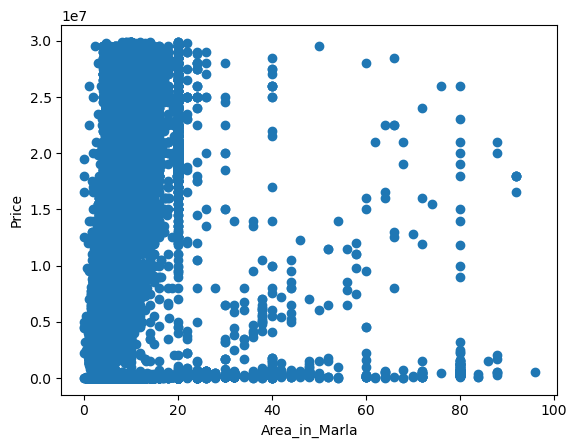

In [52]:
plt.scatter(df['Area_in_Marla'], df['price'])
plt.xlabel("Area_in_Marla")
plt.ylabel("Price")
plt.show()

In [53]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

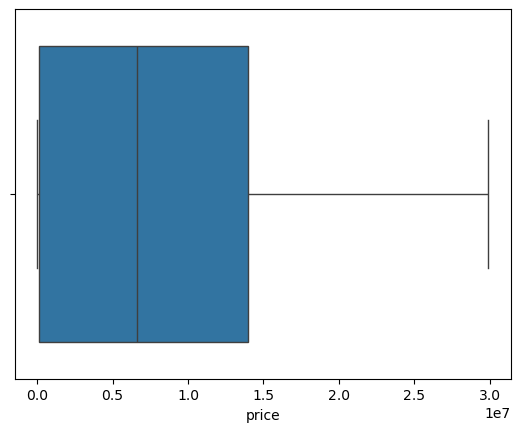

In [54]:
sns.boxplot(x=df['price'])
plt.show()

In [55]:
df['price'].describe()

count    9.221400e+04
mean     8.315569e+06
std      7.927100e+06
min      1.550000e+04
25%      1.100000e+05
50%      6.600000e+06
75%      1.400000e+07
max      2.990000e+07
Name: price, dtype: float64

In [57]:
X = df[['Area_in_Marla', 'bedrooms', 'baths', 'location']]
y = df['price']

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.24186494539524228


In [60]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))